# Drop Logger — Data Evaluation

Evaluate a downloaded drop logger CSV file.  This notebook covers:
- **Timing** — median / maximum sample interval, write-pause detection
- **Statistics** — min, max, mean, std for every measured channel
- **Time-series plots** — pressure, acceleration and rotation on a shared time axis
- **Sample rate** — instantaneous Hz over time to visualise write-flush pauses
- **Terminal velocity** — pressure plateau detection during freefall
- **Tumble frequency** — PSD of gyro signals during freefall
- **Pressure noise floor** — sensor noise measured during the stationary post-landing phase
- **Write-pause impact** — check for stale sensor values around write-flush pauses

**How to run:** open a terminal in `desktop-tools/` and launch `jupyter notebook`.  
Set `csv_path` in the *Load data* cell to evaluate a different file.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [13]:
# -- set path to the CSV file to evaluate --
csv_path = Path('sample-data/droplogger-test-data.csv')
# -------------------------------------------

# Accept both comma and tab delimited files from logger exports.
df_raw = pd.read_csv(csv_path, sep=None, engine='python')

# The unpack script writes a reference-pressure sentinel row at time = -0.001 s.
# Extract it if present, then work with data rows only.
ref_row = df_raw[df_raw['time(s)'] < 0]
if not ref_row.empty:
    ref_pressure_hpa = ref_row['Pressure Difference(hPa)'].iloc[0]
    print(f'Reference (absolute) pressure: {ref_pressure_hpa:.3f} hPa')
    df = df_raw[df_raw['time(s)'] >= 0].copy().reset_index(drop=True)
else:
    ref_pressure_hpa = None
    print('No reference pressure row found.')
    df = df_raw.copy().reset_index(drop=True)

t_start = df['time(s)'].iloc[0]
t_end   = df['time(s)'].iloc[-1]
print(f'Rows:     {len(df)}')
print(f'Time:     {t_start:.3f} s  to  {t_end:.3f} s  ({t_end - t_start:.3f} s duration)')
df.head()

Reference (absolute) pressure: 1009.621 hPa
Rows:     869
Time:     0.004 s  to  2.999 s  (2.995 s duration)


,time(s),Pressure Difference(hPa),a(ms^-2),gX(deg/s),gY(deg/s),gZ(deg/s)
0,0.004,-0.008,0.81,-54.0,203.0,-77.0
1,0.007,-0.012,0.81,-54.0,203.0,-77.0
2,0.010,-0.009,0.81,-54.0,203.0,-77.0
3,0.013,-0.016,0.81,-52.0,190.0,-75.0
4,0.016,-0.016,0.81,-52.0,190.0,-75.0


## Timing Analysis

In [14]:
dt = df['time(s)'].diff().dropna()

median_dt = dt.median()
mean_dt   = dt.mean()
max_dt    = dt.max()
min_dt    = dt.min()
std_dt    = dt.std()
median_hz = 1.0 / median_dt

print('=== Time Step Statistics ===')
print(f'  Median dt : {median_dt * 1000:7.3f} ms  ({median_hz:.0f} Hz)')
print(f'  Mean dt   : {mean_dt   * 1000:7.3f} ms')
print(f'  Std dt    : {std_dt    * 1000:7.3f} ms')
print(f'  Min dt    : {min_dt    * 1000:7.3f} ms')
print(f'  Max dt    : {max_dt    * 1000:7.3f} ms')

# Flag any time step > 5x median as a write-flush pause.
gap_threshold = median_dt * 5
gaps = dt[dt > gap_threshold]
print(f'\nWrite pauses (dt > 5x median = {gap_threshold * 1000:.1f} ms): {len(gaps)}')
for idx, gap in gaps.items():
    print(f'  t = {df["time(s)"].iloc[idx]:.3f} s   gap = {gap * 1000:.1f} ms')

=== Time Step Statistics ===
  Median dt :   3.000 ms  (333 Hz)
  Mean dt   :   3.450 ms
  Std dt    :   2.955 ms
  Min dt    :   3.000 ms
  Max dt    :  72.000 ms

Write pauses (dt > 5x median = 15.0 ms): 5
  t = 0.097 s   gap = 72.0 ms
  t = 0.924 s   gap = 18.0 ms
  t = 1.772 s   gap = 47.0 ms
  t = 1.822 s   gap = 18.0 ms
  t = 2.672 s   gap = 18.0 ms


## Channel Statistics

In [15]:
# Compute total angular velocity as an extra summary channel
df['g_mag(deg/s)'] = np.sqrt(
    df['gX(deg/s)'] ** 2 + df['gY(deg/s)'] ** 2 + df['gZ(deg/s)'] ** 2
)

channels = {
    'Pressure Difference(hPa)' : 'Pressure diff    (hPa)',
    'a(ms^-2)'                 : 'Acceleration     (m/s^2)',
    'gX(deg/s)'                : 'Gyro X           (deg/s)',
    'gY(deg/s)'                : 'Gyro Y           (deg/s)',
    'gZ(deg/s)'                : 'Gyro Z           (deg/s)',
    'g_mag(deg/s)'             : 'Gyro magnitude   (deg/s)',
}

header = f"{'Channel':<28} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}"
print(header)
print('-' * len(header))
for col, label in channels.items():
    s = df[col]
    print(f'{label:<28} {s.min():>10.2f} {s.max():>10.2f} {s.mean():>10.2f} {s.std():>10.2f}')

Channel                             Min        Max       Mean        Std
------------------------------------------------------------------------
Pressure diff    (hPa)            -3.27      -0.01      -1.69       1.05
Acceleration     (m/s^2)           0.81     106.75      11.67      15.36
Gyro X           (deg/s)       -1098.00    1014.00      17.85     396.96
Gyro Y           (deg/s)       -1884.00    3428.00    1075.45    1491.13
Gyro Z           (deg/s)       -1083.00    1572.00     181.46     471.09
Gyro magnitude   (deg/s)          39.45    3578.44    1368.26    1385.60


## Time-Series Plots

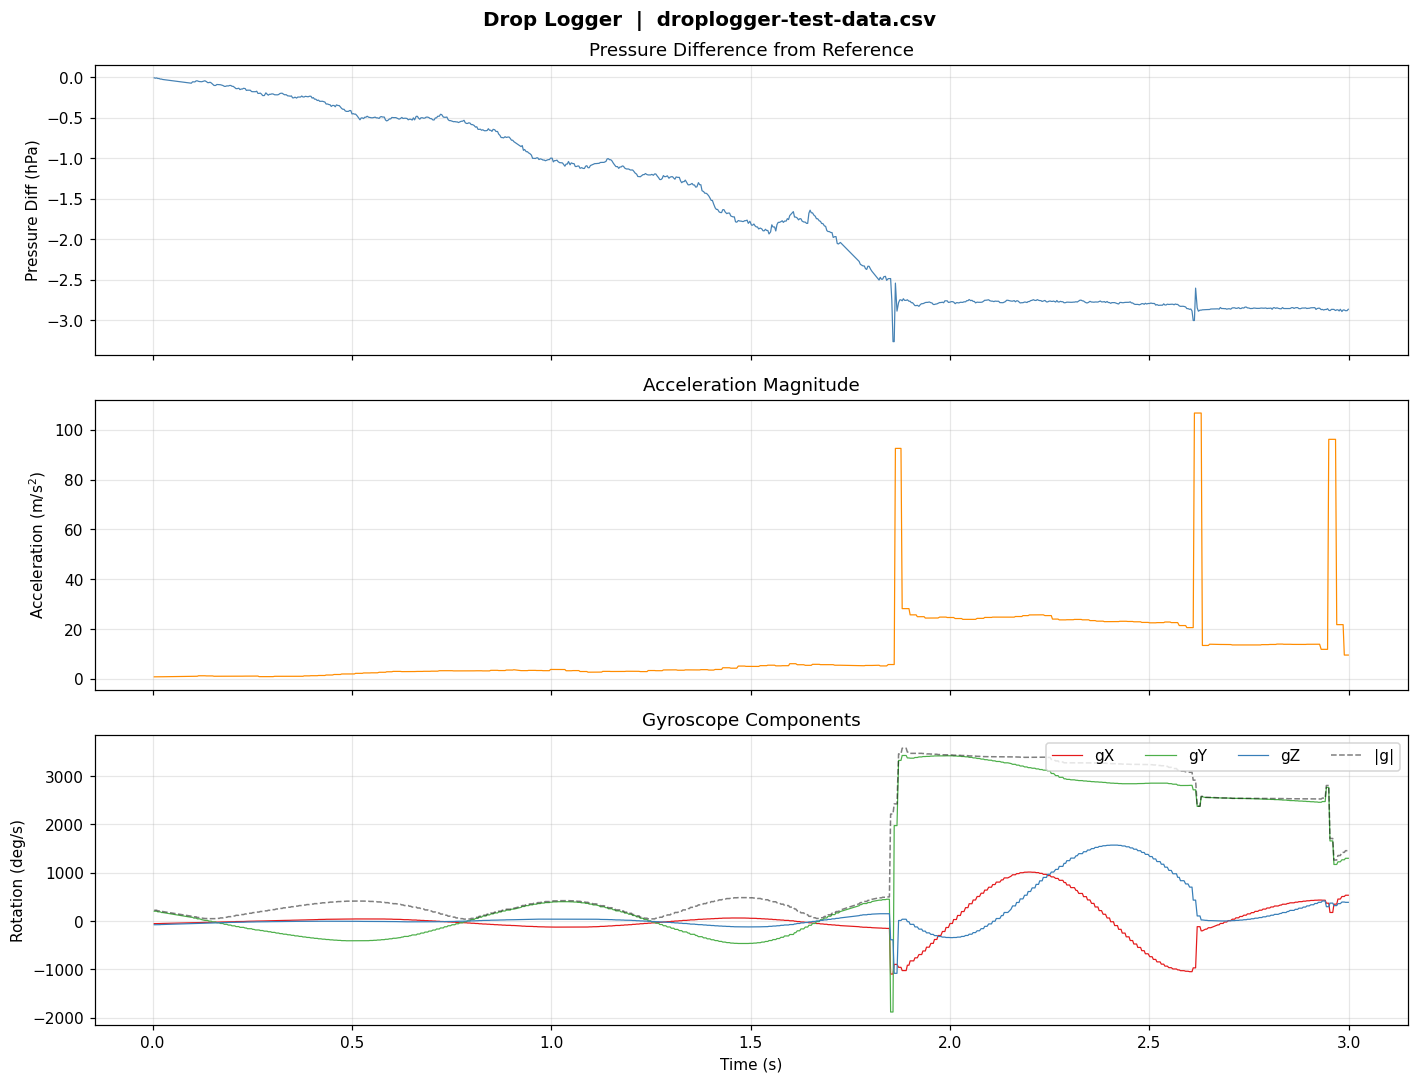

In [16]:
t = df['time(s)']

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(13, 10))
fig.suptitle(f'Drop Logger  |  {csv_path.name}', fontsize=13, fontweight='bold')

# Subplot 1 — pressure difference
axes[0].plot(t, df['Pressure Difference(hPa)'], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Pressure Diff (hPa)')
axes[0].set_title('Pressure Difference from Reference')

# Subplot 2 — acceleration magnitude
axes[1].plot(t, df['a(ms^-2)'], color='darkorange', linewidth=0.8)
axes[1].set_ylabel('Acceleration (m/s$^2$)')
axes[1].set_title('Acceleration Magnitude')

# Subplot 3 — gyroscope components + magnitude
axes[2].plot(t, df['gX(deg/s)'],    label='gX',  linewidth=0.8, color='#e41a1c')
axes[2].plot(t, df['gY(deg/s)'],    label='gY',  linewidth=0.8, color='#4daf4a')
axes[2].plot(t, df['gZ(deg/s)'],    label='gZ',  linewidth=0.8, color='#377eb8')
axes[2].plot(t, df['g_mag(deg/s)'], label='|g|', linewidth=1.0,
             color='black', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Rotation (deg/s)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Gyroscope Components')
axes[2].legend(loc='upper right', ncol=4)

plt.tight_layout()
plt.show()

## Instantaneous Sample Rate

Each dip corresponds to a write-flush pause (triggered every 500 rows).  
Sustained low rates or erratic patterns may indicate I2C contention.

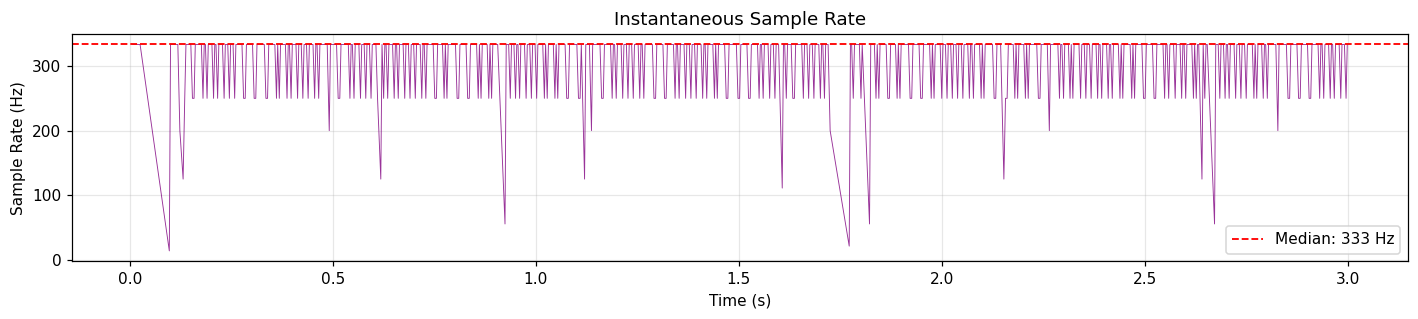

In [17]:
sample_rate = 1.0 / dt

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df['time(s)'].iloc[1:], sample_rate, color='purple', linewidth=0.6, alpha=0.8)
ax.axhline(y=median_hz, color='red', linestyle='--', linewidth=1.2,
           label=f'Median: {median_hz:.0f} Hz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Sample Rate (Hz)')
ax.set_title('Instantaneous Sample Rate')
ax.legend()
plt.tight_layout()
plt.show()

## Sensor Saturation Check

The ICM20649 gyro is configured at ±4000 deg/s.  Any sample at or near this limit has clipped data — rotational rates were higher than the sensor can measure.

In [18]:
GYRO_LIMIT = 4000  # deg/s — hardware maximum at the configured range
SAT_MARGIN = 10    # flag samples within this many deg/s of the limit

for axis in ['gX(deg/s)', 'gY(deg/s)', 'gZ(deg/s)']:
    sat = df[df[axis].abs() >= (GYRO_LIMIT - SAT_MARGIN)]
    if sat.empty:
        print(f'{axis}: no saturation')
    else:
        print(f'{axis}: {len(sat)} saturated sample(s)  '
              f'(peak = {df[axis].abs().max():.0f} deg/s  '
              f'at t = {df.loc[df[axis].abs().idxmax(), "time(s)"]:.3f} s)')

gX(deg/s): no saturation
gY(deg/s): no saturation
gZ(deg/s): no saturation


## Terminal Velocity

Terminal velocity is reached when the altitude (and therefore pressure) stops changing during freefall.  The pressure derivative flattens to near zero at this point.  
The analysis looks for the longest plateau window where the rolling pressure gradient is below a small threshold.

Longest pressure plateau: 2.286 s to 2.296 s  (0.010 s, 4 samples)
Threshold used: |dp/dt| < 0.3 m/s


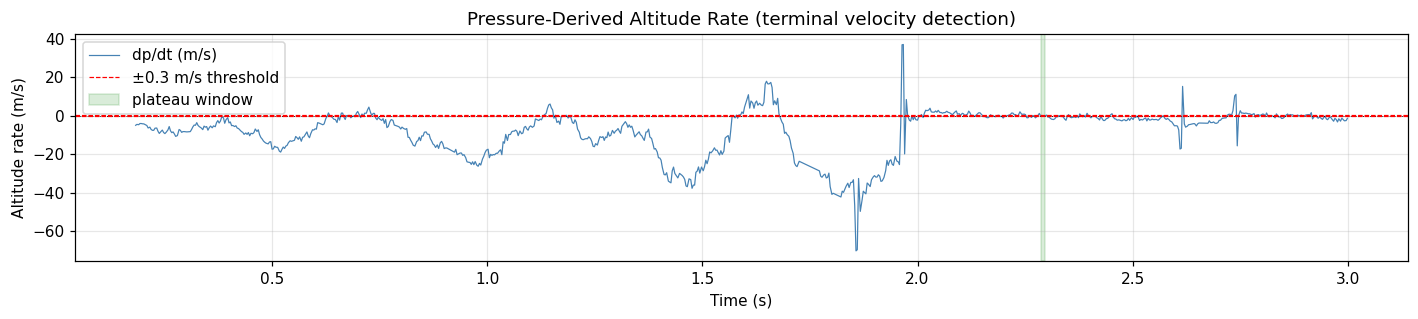

In [19]:
# Approximate altitude change from pressure: dh ~ dp * 8.5 m/hPa
SCALE_M_PER_HPA = 8.5
df['alt_change(m)'] = df['Pressure Difference(hPa)'] * SCALE_M_PER_HPA

# Rolling rate of altitude change (m/s) — use a 0.1 s window
window = max(1, int(0.1 / median_dt))
alt_rate = df['alt_change(m)'].diff(window) / (df['time(s)'].diff(window))

PLATEAU_THRESHOLD = 0.3  # m/s — rate below this = effectively constant altitude
plateau_mask = alt_rate.abs() < PLATEAU_THRESHOLD

# Find the longest consecutive plateau run
best_start = best_end = best_len = 0
run_start = None
for idx, val in plateau_mask.items():
    if val:
        if run_start is None:
            run_start = idx
    else:
        if run_start is not None:
            run_len = idx - run_start
            if run_len > best_len:
                best_len, best_start, best_end = run_len, run_start, idx - 1
            run_start = None

if best_len > 0:
    t_tv_start = df['time(s)'].iloc[best_start]
    t_tv_end   = df['time(s)'].iloc[best_end]
    print(f'Longest pressure plateau: {t_tv_start:.3f} s to {t_tv_end:.3f} s  '
          f'({t_tv_end - t_tv_start:.3f} s, {best_len} samples)')
    print(f'Threshold used: |dp/dt| < {PLATEAU_THRESHOLD} m/s')
else:
    print('No pressure plateau detected at the given threshold.')

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df['time(s)'].iloc[window:], alt_rate.iloc[window:],
        color='steelblue', linewidth=0.8, label='dp/dt (m/s)')
ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
ax.axhline( PLATEAU_THRESHOLD, color='red', linewidth=0.8, linestyle='--', label=f'±{PLATEAU_THRESHOLD} m/s threshold')
ax.axhline(-PLATEAU_THRESHOLD, color='red', linewidth=0.8, linestyle='--')
if best_len > 0:
    ax.axvspan(t_tv_start, t_tv_end, alpha=0.15, color='green', label='plateau window')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Altitude rate (m/s)')
ax.set_title('Pressure-Derived Altitude Rate (terminal velocity detection)')
ax.legend()
plt.tight_layout()
plt.show()

## Tumble Frequency (Power Spectral Density)

Applies Welch's method to the gyro signals to characterise the dominant tumble frequency during freefall.  The freefall window is defined as samples where acceleration magnitude is below a threshold.

Freefall window: 429 samples  (0.004 s to 1.520 s)


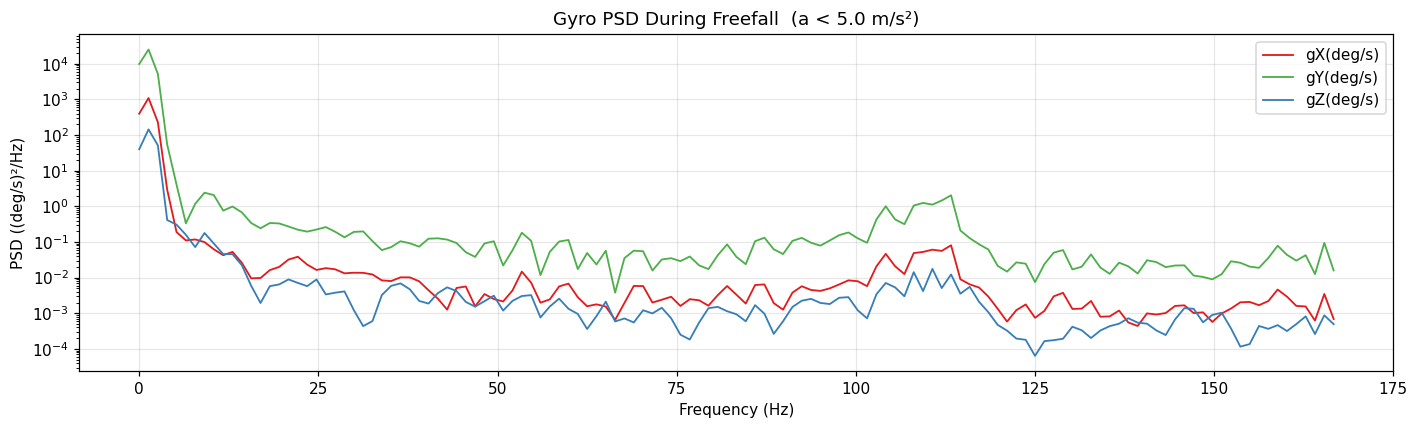


Dominant tumble frequency per axis:
  gX(deg/s): 1.30 Hz
  gY(deg/s): 1.30 Hz
  gZ(deg/s): 1.30 Hz


In [20]:
from scipy import signal as scipy_signal

FREEFALL_ACCEL_THRESHOLD = 5.0  # m/s^2
ff_mask = df['a(ms^-2)'] < FREEFALL_ACCEL_THRESHOLD
df_ff = df[ff_mask]

if len(df_ff) < 64:
    print(f'Not enough freefall samples (need ≥64, got {len(df_ff)}) — '
          f'try raising FREEFALL_ACCEL_THRESHOLD.')
else:
    fs = median_hz  # samples per second
    print(f'Freefall window: {len(df_ff)} samples  '
          f'({df_ff["time(s)"].iloc[0]:.3f} s to {df_ff["time(s)"].iloc[-1]:.3f} s)')

    fig, ax = plt.subplots(figsize=(13, 4))
    colors = {'gX(deg/s)': '#e41a1c', 'gY(deg/s)': '#4daf4a', 'gZ(deg/s)': '#377eb8'}
    for col, color in colors.items():
        f_psd, psd = scipy_signal.welch(df_ff[col].values, fs=fs,
                                        nperseg=min(256, len(df_ff)))
        ax.semilogy(f_psd, psd, label=col, linewidth=1.2, color=color)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD ((deg/s)²/Hz)')
    ax.set_title(f'Gyro PSD During Freefall  (a < {FREEFALL_ACCEL_THRESHOLD} m/s²)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Report dominant frequency for each axis
    print('\nDominant tumble frequency per axis:')
    for col, color in colors.items():
        f_psd, psd = scipy_signal.welch(df_ff[col].values, fs=fs,
                                        nperseg=min(256, len(df_ff)))
        dominant_f = f_psd[psd.argmax()]
        print(f'  {col}: {dominant_f:.2f} Hz')

## Pressure Noise Floor

Computes the standard deviation of pressure readings during the post-landing stationary phase (after peak impact).  This gives a real-world noise estimate for the BMP sensor in your operating conditions.

In [21]:
IMPACT_THRESHOLD = 20.0   # m/s^2 — above this = impact event
LANDED_ACCEL_MAX = 15.0   # m/s^2 — below this after impact = on ground
MIN_LANDED_SAMPLES = 30

impact_idx = df['a(ms^-2)'].idxmax()
t_impact   = df.loc[impact_idx, 'time(s)']
peak_a     = df.loc[impact_idx, 'a(ms^-2)']

post_impact = df[df['time(s)'] > t_impact]
landed_mask = post_impact['a(ms^-2)'] < LANDED_ACCEL_MAX
df_landed   = post_impact[landed_mask]

print(f'Peak impact: {peak_a:.2f} m/s^2 at t = {t_impact:.3f} s')

if len(df_landed) >= MIN_LANDED_SAMPLES:
    noise_std  = df_landed['Pressure Difference(hPa)'].std()
    noise_mean = df_landed['Pressure Difference(hPa)'].mean()
    print(f'Post-landing samples: {len(df_landed)}  '
          f'(t = {df_landed["time(s)"].iloc[0]:.3f} s to {df_landed["time(s)"].iloc[-1]:.3f} s)')
    print(f'Pressure noise floor:  std = {noise_std:.4f} hPa  '
          f'(mean = {noise_mean:.4f} hPa)')
    print(f'Equivalent altitude noise: ±{noise_std * SCALE_M_PER_HPA * 1000:.1f} mm (1σ)')
else:
    print(f'Not enough post-landing samples (need ≥{MIN_LANDED_SAMPLES}, got {len(df_landed)}).')
    print('Try raising LANDED_ACCEL_MAX or check that the recording includes a stationary phase.')

Peak impact: 106.75 m/s^2 at t = 2.613 s
Post-landing samples: 96  (t = 2.633 s to 2.999 s)
Pressure noise floor:  std = 0.0088 hPa  (mean = -2.8562 hPa)
Equivalent altitude noise: ±74.9 mm (1σ)


## Write-Pause Impact

Checks whether sensor values are repeated (stale) immediately before and after each write-flush pause.  A repeated value indicates the sensor was not read during the pause and the firmware reused the last sample.

In [22]:
# Re-derive gap indices from the timing analysis above
gap_indices = list(gaps.index)  # row indices where the pause begins

check_cols = ['Pressure Difference(hPa)', 'a(ms^-2)', 'gX(deg/s)', 'gY(deg/s)', 'gZ(deg/s)']

if not gap_indices:
    print('No write pauses detected — nothing to check.')
else:
    stale_count = 0
    for gap_idx in gap_indices:
        if gap_idx == 0:
            continue
        t_gap  = df['time(s)'].iloc[gap_idx]
        before = df.iloc[gap_idx - 1]
        after  = df.iloc[gap_idx]
        repeated = [c for c in check_cols if before[c] == after[c]]
        status = f'STALE: {repeated}' if repeated else 'ok'
        if repeated:
            stale_count += 1
        print(f't = {t_gap:.3f} s  gap = {gaps[gap_idx]*1000:.0f} ms  → {status}')

    print(f'\n{stale_count}/{len(gap_indices)} pauses have at least one repeated channel value.')

t = 0.097 s  gap = 72 ms  → ok
t = 0.924 s  gap = 18 ms  → ok
t = 1.772 s  gap = 47 ms  → ok
t = 1.822 s  gap = 18 ms  → ok
t = 2.672 s  gap = 18 ms  → ok

0/5 pauses have at least one repeated channel value.
